In [34]:
# MELA Project - Step 2: Annotation Center Transformation to Canonical Voxel Space

# Step 2 - Annotation Center Transformation to Canonical Voxel Space

In this step, lesion bounding box centers provided in the MELA annotation file are transformed from the original voxel coordinate system into the canonical RAS voxel space.

Since CT volumes are reoriented using `nibabel.as_closest_canonical()`, it is necessary to transform annotation coordinates accordingly to maintain spatial consistency between image data and bounding boxes.

The transformation is performed in two stages:
1. Original voxel coordinates → world coordinates using the original affine matrix
2. World coordinates → canonical voxel coordinates using the inverse canonical affine matrix

## Objective

- Load annotation data from CSV
- Match each CT volume with its corresponding annotation
- Transform lesion center coordinates into canonical voxel space
- Verify spatial correctness via visualization

## Validation Strategy

The correctness of the transformation is validated using:

- Center position visualization on canonical images
- Bounding box consistency checks
- Comparison between expected and computed bounding box centers
- Mask voxel count verification
- Slice-wise spatial continuity analysis

This validation ensures that annotation coordinates are correctly aligned with the transformed CT volumes.

## Important Note

The MELA dataset provides 3D bounding box annotations rather than pixel-wise segmentation masks.

Therefore, any generated masks in this project are considered **pseudo-masks** and should not be interpreted as clinical ground truth.

These pseudo-masks are suitable for:
- weakly supervised learning
- localization tasks
- preliminary segmentation modeling
## Manual Validation

A manual validation block is implemented to verify:

- Annotation-to-image consistency
- Correct transformation of lesion center coordinates
- Bounding box correctness
- Mask generation accuracy
- Stability across multiple slices

This step is critical before scaling the pipeline to the full dataset.

## Conclusion

The annotation center transformation pipeline successfully maps bounding box centers from the original voxel space to the canonical voxel space.

Validation results confirm that:
- The transformation is mathematically consistent
- Bounding boxes are correctly positioned in canonical space
- Generated pseudo-masks align with expected regions

This step prepares the dataset for large-scale pseudo-mask generation and downstream deep learning tasks.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
!pip install nibabel pandas matplotlib -q

In [37]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [38]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [39]:
BASE = "/content/drive/MyDrive/MELA"
TRAIN_DIR = os.path.join(BASE, "images", "train")
ANN_DIR = os.path.join(BASE, "annotations")

print("BASE:", BASE)
print("TRAIN_DIR:", TRAIN_DIR)
print("ANN_DIR:", ANN_DIR)

BASE: /content/drive/MyDrive/MELA
TRAIN_DIR: /content/drive/MyDrive/MELA/images/train
ANN_DIR: /content/drive/MyDrive/MELA/annotations


In [40]:
train_files = sorted([f for f in os.listdir(TRAIN_DIR) if f.endswith(".nii.gz")])

print("Train dosya sayısı:", len(train_files))
print("İlk 5 train dosyası:", train_files[:5])

Train dosya sayısı: 260
İlk 5 train dosyası: ['mela_0001.nii.gz', 'mela_0002.nii.gz', 'mela_0003.nii.gz', 'mela_0004.nii.gz', 'mela_0005.nii.gz']


In [41]:
ann_path = os.path.join(ANN_DIR, "mela_train_val_annotations.csv")
spacing_path = os.path.join(ANN_DIR, "mela_origin_spacing.csv")

df_ann = pd.read_csv(ann_path)
df_spacing = pd.read_csv(spacing_path)

print("Annotation kolonları:", df_ann.columns.tolist())
print("Spacing kolonları:", df_spacing.columns.tolist())
print("Toplam annotation satırı:", len(df_ann))
print("Toplam spacing satırı:", len(df_spacing))

Annotation kolonları: ['public_id', 'coordX', 'coordY', 'coordZ', 'x_length', 'y_length', 'z_length']
Spacing kolonları: ['public_id', 'origin_x', 'origin_y', 'origin_z', 'spacing_x', 'spacing_y', 'spacing_z']
Toplam annotation satırı: 884
Toplam spacing satırı: 880


In [42]:
sample_file = train_files[5]
sample_id = sample_file.replace(".nii.gz", "")
sample_path = os.path.join(TRAIN_DIR, sample_file)

print("Sample file:", sample_file)
print("Sample ID:", sample_id)
print("Sample path:", sample_path)

Sample file: mela_0006.nii.gz
Sample ID: mela_0006
Sample path: /content/drive/MyDrive/MELA/images/train/mela_0006.nii.gz


In [43]:
img = nib.load(sample_path)
img_data = img.get_fdata()

img_canon = nib.as_closest_canonical(img)
img_data_canon = img_canon.get_fdata()

print("Original shape:", img_data.shape)
print("Canonical shape:", img_data_canon.shape)
print("Original axis codes :", nib.aff2axcodes(img.affine))
print("Canonical axis codes:", nib.aff2axcodes(img_canon.affine))

Original shape: (512, 512, 579)
Canonical shape: (512, 512, 579)
Original axis codes : ('L', 'P', 'S')
Canonical axis codes: ('R', 'A', 'S')


In [44]:
sample_ann = df_ann[df_ann["public_id"] == sample_id]
sample_spacing = df_spacing[df_spacing["public_id"] == sample_id]

print("Sample annotation:")
print(sample_ann)

print("\nSample spacing:")
print(sample_spacing)

Sample annotation:
   public_id  coordX  coordY  coordZ  x_length  y_length  z_length
5  mela_0006     266     155     329        32        38        50

Sample spacing:
   public_id    origin_x    origin_y    origin_z  spacing_x  spacing_y  \
5  mela_0006 -200.632812 -321.132812 -457.600006   0.734375   0.734375   

   spacing_z  
5   0.700012  


In [45]:
row = sample_ann.iloc[0]

cx = float(row["coordX"])
cy = float(row["coordY"])
cz = float(row["coordZ"])

lx = float(row["x_length"])
ly = float(row["y_length"])
lz = float(row["z_length"])

print("Original voxel center:", (cx, cy, cz))
print("BBox lengths:", (lx, ly, lz))

Original voxel center: (266.0, 155.0, 329.0)
BBox lengths: (32.0, 38.0, 50.0)


In [46]:
row = sample_ann.iloc[0]

cx = float(row["coordX"])
cy = float(row["coordY"])
cz = float(row["coordZ"])

lx = float(row["x_length"])
ly = float(row["y_length"])
lz = float(row["z_length"])

print("Original voxel center:", (cx, cy, cz))
print("BBox lengths:", (lx, ly, lz))

Original voxel center: (266.0, 155.0, 329.0)
BBox lengths: (32.0, 38.0, 50.0)


In [47]:
center_old_voxel = np.array([cx, cy, cz, 1.0])
print("Old voxel center (homogeneous):", center_old_voxel)

Old voxel center (homogeneous): [266. 155. 329.   1.]


In [48]:
center_world = img.affine @ center_old_voxel

print("World coordinate center:", center_world[:3])

World coordinate center: [   5.2890625   207.3046875  -227.29598999]


In [49]:
center_new_voxel = np.linalg.inv(img_canon.affine) @ center_world

print("Canonical voxel center:", center_new_voxel[:3])

Canonical voxel center: [245. 356. 329.]


In [50]:
print("=== Center Transformation Summary ===")
print("Sample ID:", sample_id)
print("Old voxel center      :", center_old_voxel[:3])
print("World coordinate      :", center_world[:3])
print("Canonical voxel center:", center_new_voxel[:3])

=== Center Transformation Summary ===
Sample ID: mela_0006
Old voxel center      : [266. 155. 329.]
World coordinate      : [   5.2890625   207.3046875  -227.29598999]
Canonical voxel center: [245. 356. 329.]


In [51]:
cx_new, cy_new, cz_new = center_new_voxel[:3]

print("cx_new:", cx_new)
print("cy_new:", cy_new)
print("cz_new:", cz_new)

cx_new: 245.0
cy_new: 356.0
cz_new: 329.00000000000006


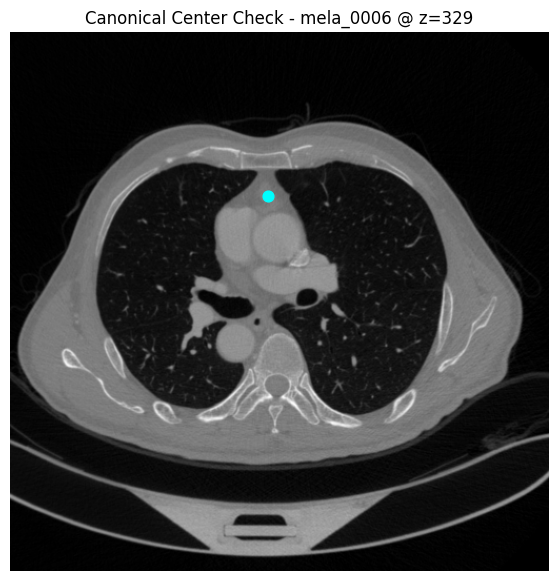

In [52]:
z_show = int(round(cz_new))

plt.figure(figsize=(7,7))
plt.imshow(img_data_canon[:, :, z_show].T, cmap="gray", origin="lower")
plt.scatter(cx_new, cy_new, c="cyan", s=60)
plt.title(f"Canonical Center Check - {sample_id} @ z={z_show}")
plt.axis("off")
plt.show()

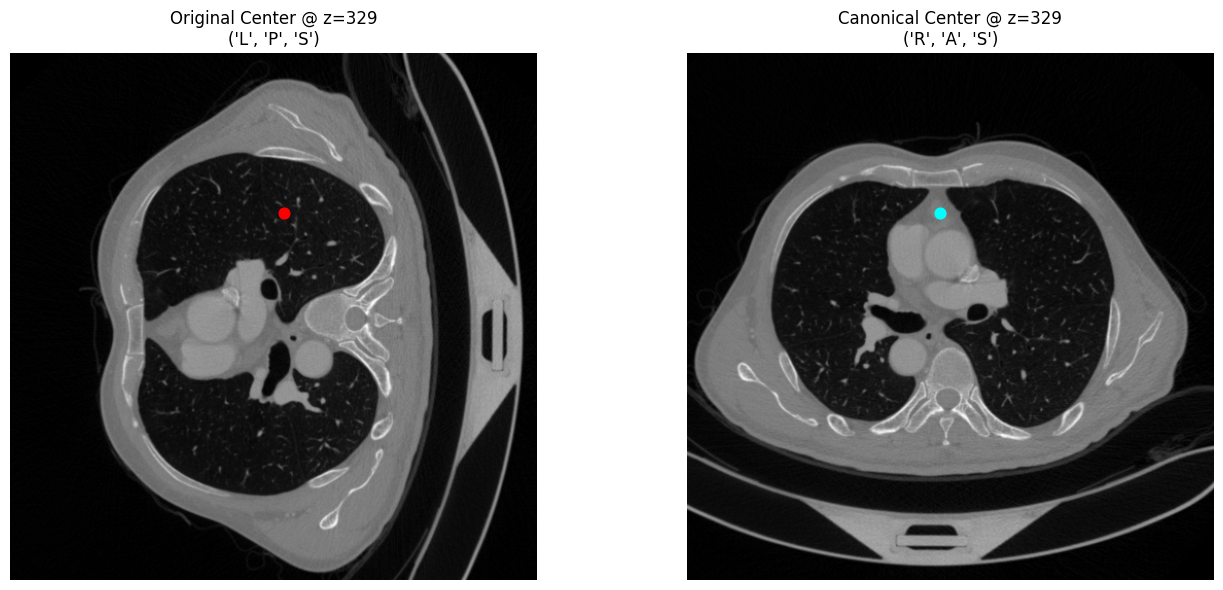

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original
z_old = int(round(cz))
axes[0].imshow(img_data[:, :, z_old], cmap="gray")
axes[0].scatter(cx, cy, c="red", s=60)
axes[0].set_title(f"Original Center @ z={z_old}\n{nib.aff2axcodes(img.affine)}")
axes[0].axis("off")

# Canonical
axes[1].imshow(img_data_canon[:, :, z_show].T, cmap="gray", origin="lower")
axes[1].scatter(cx_new, cy_new, c="cyan", s=60)
axes[1].set_title(f"Canonical Center @ z={z_show}\n{nib.aff2axcodes(img_canon.affine)}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [54]:
def transform_bbox_center_to_canonical(img, img_canon, cx, cy, cz):
    """
    Orijinal voxel uzayındaki bbox merkezini canonical voxel uzayına taşır.

    Parameters:
        img        : original nibabel NIfTI image
        img_canon  : canonical nibabel NIfTI image
        cx, cy, cz : original voxel center coordinates

    Returns:
        center_old_voxel : old voxel homogeneous coordinate
        center_world     : world coordinate
        center_new_voxel : canonical voxel homogeneous coordinate
    """
    center_old_voxel = np.array([cx, cy, cz, 1.0])
    center_world = img.affine @ center_old_voxel
    center_new_voxel = np.linalg.inv(img_canon.affine) @ center_world

    return center_old_voxel, center_world, center_new_voxel

In [55]:
center_old_voxel, center_world, center_new_voxel = transform_bbox_center_to_canonical(
    img, img_canon, cx, cy, cz
)

print("Old voxel center      :", center_old_voxel[:3])
print("World coordinate      :", center_world[:3])
print("Canonical voxel center:", center_new_voxel[:3])

Old voxel center      : [266. 155. 329.]
World coordinate      : [   5.2890625   207.3046875  -227.29598999]
Canonical voxel center: [245. 356. 329.]


In [56]:
def show_canonical_center(img_data_canon, cx_new, cy_new, cz_new, sample_id="sample"):
    z_show = int(round(cz_new))

    plt.figure(figsize=(7,7))
    plt.imshow(img_data_canon[:, :, z_show].T, cmap="gray", origin="lower")
    plt.scatter(cx_new, cy_new, c="cyan", s=60)
    plt.title(f"Canonical Center Check - {sample_id} @ z={z_show}")
    plt.axis("off")
    plt.show()

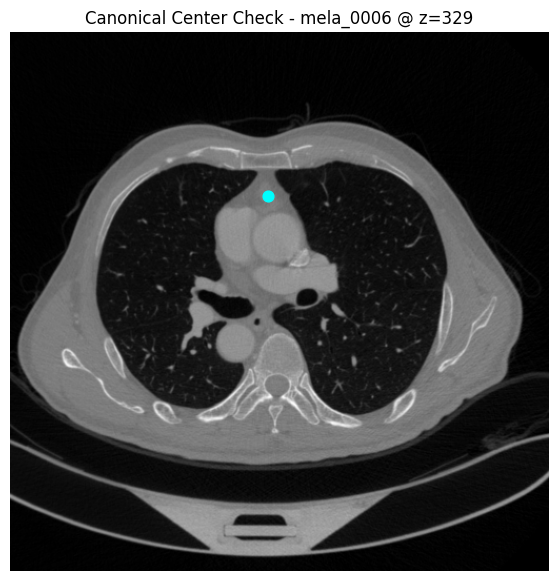

In [57]:
show_canonical_center(img_data_canon, cx_new, cy_new, cz_new, sample_id)

In [59]:
# Canonical center'dan bbox sınırlarını hesapla

x_min = int(round(cx_new - lx / 2))
x_max = int(round(cx_new + lx / 2))

y_min = int(round(cy_new - ly / 2))
y_max = int(round(cy_new + ly / 2))

z_min = int(round(cz_new - lz / 2))
z_max = int(round(cz_new + lz / 2))

# Görüntü sınırları içinde tut
x_min = max(0, x_min)
x_max = min(img_data_canon.shape[0], x_max)

y_min = max(0, y_min)
y_max = min(img_data_canon.shape[1], y_max)

z_min = max(0, z_min)
z_max = min(img_data_canon.shape[2], z_max)

print("BBox ranges computed successfully")
print("x_min, x_max:", x_min, x_max)
print("y_min, y_max:", y_min, y_max)
print("z_min, z_max:", z_min, z_max)

BBox ranges computed successfully
x_min, x_max: 229 261
y_min, y_max: 337 375
z_min, z_max: 304 354


========== BASIC FILE CHECK ==========
Sample file: mela_0006.nii.gz
Sample ID: mela_0006
Original shape: (512, 512, 579)
Canonical shape: (512, 512, 579)
Original axis codes : ('L', 'P', 'S')
Canonical axis codes: ('R', 'A', 'S')

========== ANNOTATION CHECK ==========
   public_id  coordX  coordY  coordZ  x_length  y_length  z_length
5  mela_0006     266     155     329        32        38        50

========== CENTER VALUES ==========
Original center (CSV): (266.0, 155.0, 329.0)
Canonical center     : (np.float64(245.0), np.float64(356.0), np.float64(329.00000000000006))
BBox lengths         : (32.0, 38.0, 50.0)

========== BBOX RANGE CHECK ==========
x_min, x_max: 229 261
y_min, y_max: 337 375
z_min, z_max: 304 354

========== INSIDE IMAGE CHECK ==========
Center inside X range: True
Center inside Y range: True
Center inside Z range: True

========== BBOX CENTER CHECK ==========
Expected canonical center : (np.float64(245.0), np.float64(356.0), np.float64(329.00000000000006))
Compu

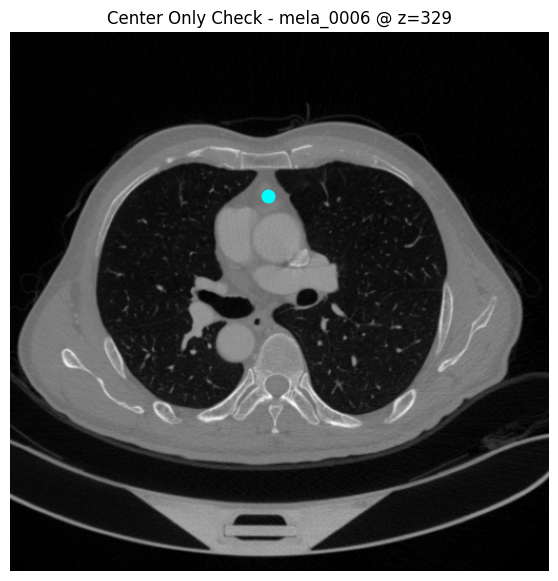

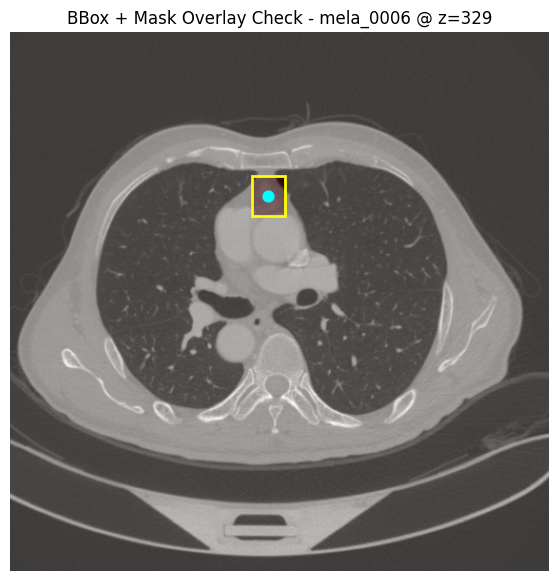


========== SLICE CONTINUITY CHECK ==========
Mask exists in slices: [304 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321
 322 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339
 340 341 342 343 344 345 346 347 348 349 350 351 352 353]


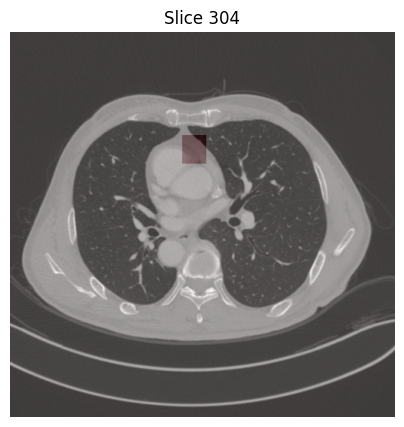

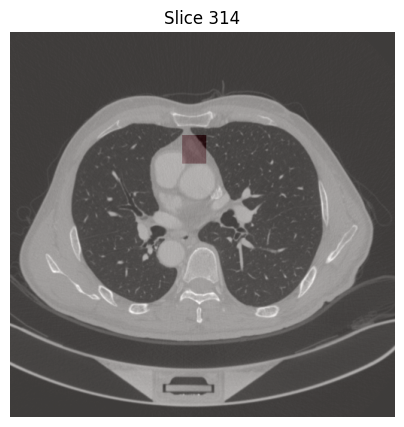

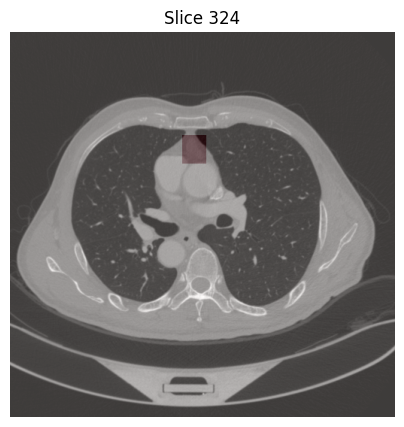

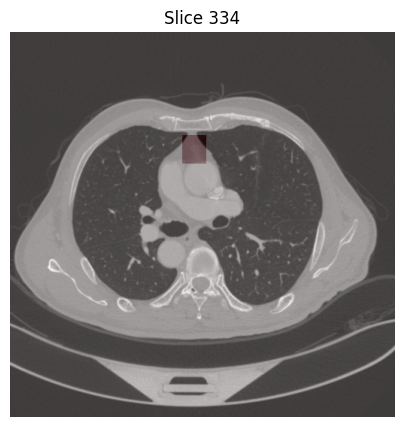

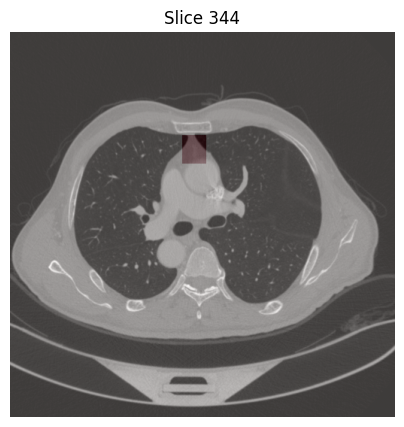


========== MANUAL INTERPRETATION GUIDE ==========
1. Cyan center point should lie inside body tissue, not outside image.
2. Yellow bbox and red mask overlay should overlap perfectly.
3. The bbox should remain in a stable anatomical region across slices.
4. Since MELA provides bounding boxes, not pixel-wise masks,
   slight mismatch with the actual lesion boundary is expected.


In [60]:
# ================================
# MANUAL VALIDATION BLOCK
# ================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import nibabel as nib

print("========== BASIC FILE CHECK ==========")
print("Sample file:", sample_file)
print("Sample ID:", sample_id)
print("Original shape:", img_data.shape)
print("Canonical shape:", img_data_canon.shape)
print("Original axis codes :", nib.aff2axcodes(img.affine))
print("Canonical axis codes:", nib.aff2axcodes(img_canon.affine))

print("\n========== ANNOTATION CHECK ==========")
print(sample_ann)

print("\n========== CENTER VALUES ==========")
print("Original center (CSV):", (cx, cy, cz))
print("Canonical center     :", (cx_new, cy_new, cz_new))
print("BBox lengths         :", (lx, ly, lz))

print("\n========== BBOX RANGE CHECK ==========")
print("x_min, x_max:", x_min, x_max)
print("y_min, y_max:", y_min, y_max)
print("z_min, z_max:", z_min, z_max)

# 1) Merkez görüntü sınırları içinde mi?
inside_x = (0 <= cx_new < img_data_canon.shape[0])
inside_y = (0 <= cy_new < img_data_canon.shape[1])
inside_z = (0 <= cz_new < img_data_canon.shape[2])

print("\n========== INSIDE IMAGE CHECK ==========")
print("Center inside X range:", inside_x)
print("Center inside Y range:", inside_y)
print("Center inside Z range:", inside_z)

# 2) BBox merkezi gerçekten hedef merkezi ortalıyor mu?
bbox_center_x = (x_min + x_max) / 2
bbox_center_y = (y_min + y_max) / 2
bbox_center_z = (z_min + z_max) / 2

print("\n========== BBOX CENTER CHECK ==========")
print("Expected canonical center :", (cx_new, cy_new, cz_new))
print("Computed bbox center      :", (bbox_center_x, bbox_center_y, bbox_center_z))
print("Center difference         :", (
    abs(cx_new - bbox_center_x),
    abs(cy_new - bbox_center_y),
    abs(cz_new - bbox_center_z)
))

# 3) Maskeyi üret
mask_canon = np.zeros_like(img_data_canon, dtype=np.uint8)
mask_canon[x_min:x_max, y_min:y_max, z_min:z_max] = 1

print("\n========== MASK VOXEL CHECK ==========")
expected_voxels = (x_max - x_min) * (y_max - y_min) * (z_max - z_min)
actual_voxels = int(mask_canon.sum())

print("Expected voxel count:", expected_voxels)
print("Actual voxel count  :", actual_voxels)

# 4) Maskeden bbox'ı geri çıkar
coords = np.argwhere(mask_canon > 0)

x_min_m, y_min_m, z_min_m = coords.min(axis=0)
x_max_m, y_max_m, z_max_m = coords.max(axis=0) + 1

print("\n========== RECOVERED BBOX FROM MASK ==========")
print("Original bbox :")
print("X:", x_min, x_max)
print("Y:", y_min, y_max)
print("Z:", z_min, z_max)

print("\nRecovered bbox:")
print("X:", x_min_m, x_max_m)
print("Y:", y_min_m, y_max_m)
print("Z:", z_min_m, z_max_m)

# 5) Sadece merkezi göster
z_show = int(round(cz_new))

plt.figure(figsize=(7, 7))
plt.imshow(img_data_canon[:, :, z_show].T, cmap="gray", origin="lower")
plt.scatter(cx_new, cy_new, c="cyan", s=80)
plt.title(f"Center Only Check - {sample_id} @ z={z_show}")
plt.axis("off")
plt.show()

# 6) Aynı slice'ta bbox + overlay birlikte göster
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img_data_canon[:, :, z_show].T, cmap="gray", origin="lower")
ax.imshow(mask_canon[:, :, z_show].T, cmap="Reds", alpha=0.25, origin="lower")

rect = patches.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth=2,
    edgecolor="yellow",
    facecolor="none"
)
ax.add_patch(rect)

ax.scatter(cx_new, cy_new, c="cyan", s=60)
ax.set_title(f"BBox + Mask Overlay Check - {sample_id} @ z={z_show}")
ax.axis("off")
plt.show()

# 7) Slice continuity check
print("\n========== SLICE CONTINUITY CHECK ==========")
slices = np.where(mask_canon.sum(axis=(0, 1)) > 0)[0]
print("Mask exists in slices:", slices)

for z in slices[::max(1, len(slices)//5)]:
    plt.figure(figsize=(5, 5))
    plt.imshow(img_data_canon[:, :, z].T, cmap="gray", origin="lower")
    plt.imshow(mask_canon[:, :, z].T, cmap="Reds", alpha=0.25, origin="lower")
    plt.title(f"Slice {z}")
    plt.axis("off")
    plt.show()

print("\n========== MANUAL INTERPRETATION GUIDE ==========")
print("1. Cyan center point should lie inside body tissue, not outside image.")
print("2. Yellow bbox and red mask overlay should overlap perfectly.")
print("3. The bbox should remain in a stable anatomical region across slices.")
print("4. Since MELA provides bounding boxes, not pixel-wise masks,")
print("   slight mismatch with the actual lesion boundary is expected.")